## What are the most demanded skills for top 3 most popular data Roles?

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import locale
import ast
locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')  # Força locale para inglês

#Getting the data
df = pd.read_csv('data_jobs.csv')

#data cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

#### Filtering and getting the skills

In [69]:
#Filter
df_US = df[df['job_country'] == 'United States']


#Exploding and getting the count
df_skills = df_US.explode('job_skills')
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values('skill_count', ascending=False, inplace=True)

#Getting the top job_titles
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3]) #Getting the top

#### Converting counts to percent

Counts don't show what portions of jobs are requesting these skills

In [70]:
#Getting the porcentage of the skills
df_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')
df_skills_porc = pd.merge(df_skills_count, df_title_count, how = 'left', on='job_title_short')
df_skills_porc['skill_porcent'] = 100 * df_skills_porc['skill_count']/df_skills_porc['jobs_total']
df_skills_porc

,job_skills,job_title_short,skill_count,jobs_total,skill_porcent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


#### Visualizing Percentage Count

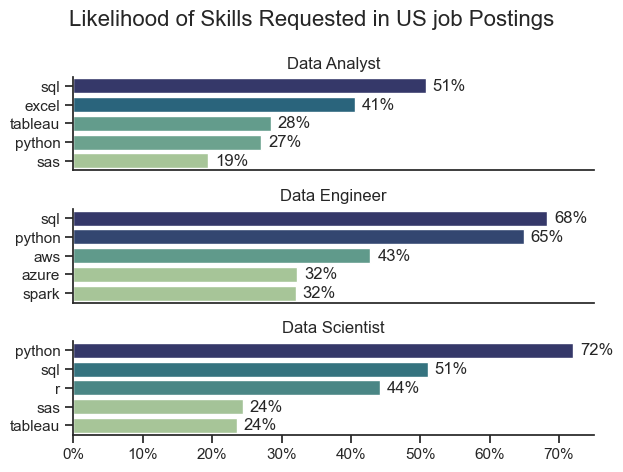

In [92]:
fig, ax = plt.subplots(len(job_titles), 1)
sns.set_theme(style='ticks')

for i,job_title in enumerate(job_titles):
    #Plotting
    df_plot = df_skills_porc[df_skills_porc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_porcent', y='job_skills', ax=ax[i],
                hue='skill_count', palette='crest',legend=False)
    
    
    #formatting
    ax[i].set_title(job_title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].spines['top'].set_visible(False) 
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,75)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'{int(x)}%'))
    
    #Getting the porcentage
    for n, value in enumerate(df_plot['skill_porcent']):
        ax[i].text(value + 1, #X position
                    n, # Y position
                    f'{value:.0f}%', #What will be printed
                    va='center' #vertical position
                    )
    if i != len(job_titles)-1: #Keeps the last one
        ax[i].set_xticks([])



fig.suptitle('Likelihood of Skills Requested in US job Postings',fontsize=16)
plt.tight_layout()
plt.show()